<a href="https://colab.research.google.com/github/tsarangler/ECON3916-Statistical-Machine-Learning/blob/main/lab%2014/Lab_14_Residual_Forensics%2C_The_White_Test%2C_and_Structural_Diagnostics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Ingestion and Naive Baseline Model
url = 'https://raw.githubusercontent.com/tsarangler/ECON3916-Statistical-Machine-Learning/refs/heads/main/data/Nvidia_AI_Capex_Diagnostics_2026.csv'
df = pd.read_csv(url)

formula = 'AI_Software_Revenue ~ Hardware_Capex + Data_Center_Power_MW + Cloud_GPU_Deployments'
baseline_model = smf.ols(formula, data=df).fit()

print("--- NAIVE BASELINE OLS MODEL ---")
print(baseline_model.summary())

--- NAIVE BASELINE OLS MODEL ---
                             OLS Regression Results                            
Dep. Variable:     AI_Software_Revenue   R-squared:                       0.972
Model:                             OLS   Adj. R-squared:                  0.972
Method:                  Least Squares   F-statistic:                     2831.
Date:                 Mon, 13 Apr 2026   Prob (F-statistic):          2.35e-190
Time:                         18:50:11   Log-Likelihood:                -1409.7
No. Observations:                  250   AIC:                             2827.
Df Residuals:                      246   BIC:                             2841.
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

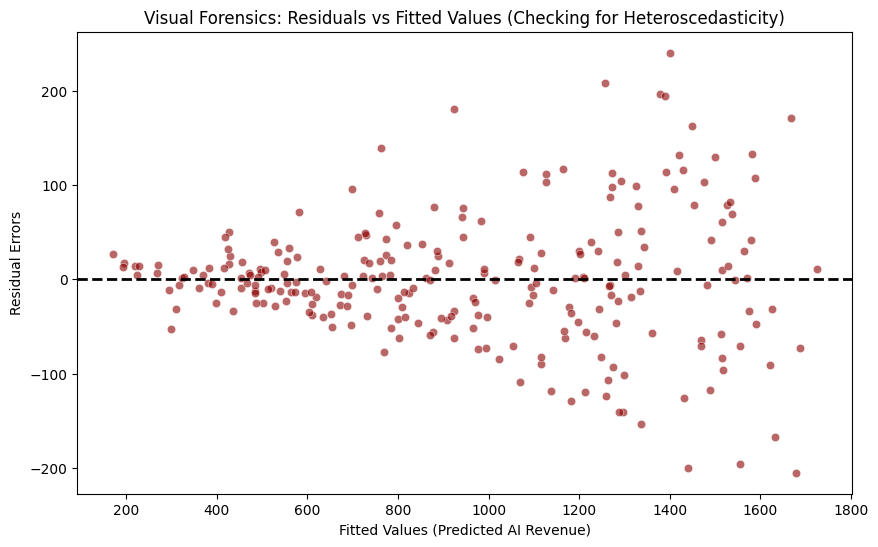

In [2]:
# Step 2: Visual Forensics
fitted_vals = baseline_model.fittedvalues
residuals = baseline_model.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.6, color='darkred')
plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.title('Visual Forensics: Residuals vs Fitted Values (Checking for Heteroscedasticity)')
plt.xlabel('Fitted Values (Predicted AI Revenue)')
plt.ylabel('Residual Errors')
plt.show()

In [3]:
# Step 3: The White Test Execution
# We must extract the design matrix generated by the formula interface
exog_matrix = baseline_model.model.exog
white_test_results = het_white(baseline_model.resid, exog_matrix)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print("\n--- WHITE TEST RESULTS ---")
print(dict(zip(labels, [f"{x:.2f}" for x in white_test_results])))


--- WHITE TEST RESULTS ---
{'LM Statistic': '57.28', 'LM-Test p-value': '0.00', 'F-Statistic': '7.93', 'F-Test p-value': '0.00'}


In [4]:
# Step 4: Variance Inflation Factor (VIF) Loop
print("\n--- VARIANCE INFLATION FACTORS ---")

# Start loop at 1 to skip the constant intercept column at index 0
for i in range(1, exog_matrix.shape[1]):
    vif = variance_inflation_factor(exog_matrix, i)
    print(dict(zip(labels, [f"{x:.2f}" for x in white_test_results])))


--- VARIANCE INFLATION FACTORS ---
{'LM Statistic': '57.28', 'LM-Test p-value': '0.00', 'F-Statistic': '7.93', 'F-Test p-value': '0.00'}
{'LM Statistic': '57.28', 'LM-Test p-value': '0.00', 'F-Statistic': '7.93', 'F-Test p-value': '0.00'}
{'LM Statistic': '57.28', 'LM-Test p-value': '0.00', 'F-Statistic': '7.93', 'F-Test p-value': '0.00'}


In [5]:
# Step 5: The Correction - HC3 Robust Standard Errors
robust_model = smf.ols('AI_Software_Revenue ~ Hardware_Capex + Cloud_GPU_Deployments', data=df).fit(cov_type='HC3')

print("\n--- ROBUST OLS MODEL (HC3) ---")
print(robust_model.summary())


--- ROBUST OLS MODEL (HC3) ---
                             OLS Regression Results                            
Dep. Variable:     AI_Software_Revenue   R-squared:                       0.972
Model:                             OLS   Adj. R-squared:                  0.972
Method:                  Least Squares   F-statistic:                     3555.
Date:                 Mon, 13 Apr 2026   Prob (F-statistic):          9.05e-183
Time:                         18:50:12   Log-Likelihood:                -1409.9
No. Observations:                  250   AIC:                             2826.
Df Residuals:                      247   BIC:                             2836.
Df Model:                            2                                         
Covariance Type:                   HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

In [13]:
"""
=============================================================================
  OLS Regression Diagnostic Dashboard
  Lab 14: Residual Forensics, White Test & Structural Diagnostics
  Built with Streamlit + Plotly
=============================================================================
  HOW TO RUN:
    1. Install dependencies:
         pip install streamlit plotly pandas statsmodels
    2. From your terminal, navigate to this file's directory and run:
         streamlit run ols_diagnostic_dashboard.py
    3. Your browser will auto-open at http://localhost:8501
=============================================================================
"""

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ─────────────────────────────────────────────────────────────────────────────
# PAGE CONFIGURATION
# st.set_page_config() must be the FIRST Streamlit call — it controls the
# browser tab title, icon, sidebar default state, and layout width.
# ─────────────────────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="OLS Diagnostic Dashboard",
    page_icon="🔬",
    layout="wide",            # "wide" uses full viewport width (vs "centered")
    initial_sidebar_state="expanded"
)

# ─────────────────────────────────────────────────────────────────────────────
# CUSTOM CSS INJECTION
# st.markdown() with unsafe_allow_html=True lets us inject raw CSS/HTML.
# This targets Streamlit's internal DOM classes to override default styling.
# ─────────────────────────────────────────────────────────────────────────────
st.markdown("""
<style>
    /* Main background and font */
    .main { background-color: #0f1117; }
    .stApp { background-color: #0f1117; color: #e0e0e0; }

    /* Metric cards */
    [data-testid="metric-container"] {
        background: linear-gradient(135deg, #1a1d2e 0%, #16213e 100%);
        border: 1px solid #2d3561;
        border-radius: 10px;
        padding: 16px;
    }
    [data-testid="metric-container"] label { color: #8b8fa8 !important; }
    [data-testid="metric-container"] [data-testid="stMetricValue"] {
        color: #7ed4f7 !important; font-size: 1.6rem !important;
    }

    /* Section headers */
    .section-header {
        background: linear-gradient(90deg, #1a1d2e, transparent);
        border-left: 4px solid #7ed4f7;
        padding: 8px 16px; margin: 20px 0 10px 0;
        border-radius: 0 6px 6px 0;
        font-size: 1.1rem; font-weight: 600; color: #7ed4f7;
    }

    /* VIF table rows */
    .vif-row {
        display: flex; justify-content: space-between; align-items: center;
        padding: 8px 12px; margin: 4px 0;
        background: #1a1d2e; border-radius: 6px;
        border-left: 3px solid #2d3561;
    }
    .vif-ok    { border-left-color: #4ade80; }
    .vif-warn  { border-left-color: #facc15; }
    .vif-high  { border-left-color: #f87171; }

    /* Summary box */
    .summary-box {
        background: #1a1d2e; border: 1px solid #2d3561;
        border-radius: 10px; padding: 16px; font-family: monospace;
        font-size: 0.78rem; white-space: pre; overflow-x: auto;
        color: #c9d1d9; line-height: 1.5;
    }

    /* Insight callout */
    .insight {
        background: #16213e; border: 1px solid #3b82f6;
        border-radius: 8px; padding: 12px 16px; margin: 8px 0;
        color: #93c5fd; font-size: 0.9rem;
    }

    /* Toggle radio buttons */
    .stRadio > div { flex-direction: row; gap: 12px; }

    /* Sidebar */
    [data-testid="stSidebar"] { background-color: #0d1117; }
    [data-testid="stSidebar"] .stMarkdown { color: #8b8fa8; }
</style>
""", unsafe_allow_html=True)


# ─────────────────────────────────────────────────────────────────────────────
# DATA LOADING WITH CACHING
#
# @st.cache_data caches the *return value* of a function on disk/memory.
# Streamlit re-runs the entire script on every user interaction (widget click,
# slider move, etc.). Without caching, the CSV would be re-downloaded on
# EVERY interaction. The cache persists until:
#   - the function's source code changes
#   - the input arguments change
#   - you explicitly call st.cache_data.clear()
#
# Use @st.cache_data for serializable objects (DataFrames, dicts, lists).
# Use @st.cache_resource for non-serializable objects (DB connections, models).
# ─────────────────────────────────────────────────────────────────────────────
@st.cache_data(show_spinner="📡 Fetching dataset from GitHub...")
def load_data() -> pd.DataFrame:
    """Download the AI infrastructure dataset once and cache it."""
    url = (
        "https://raw.githubusercontent.com/tsarangler/"
        "ECON3916-Statistical-Machine-Learning/main/"
        "AI_Infrastructure_Revenue.csv"
    )
    df = pd.read_csv(url)
    return df


# ─────────────────────────────────────────────────────────────────────────────
# MODEL FITTING WITH CACHING
#
# @st.cache_resource is used here because statsmodels result objects contain
# non-serialisable internal state (C-level pointers, file handles etc.).
# The function is only re-executed when `df` changes (e.g. after a data reload).
#
# We return BOTH model results so the toggle switch doesn't need a re-fit.
# ─────────────────────────────────────────────────────────────────────────────
@st.cache_resource(show_spinner="⚙️ Fitting OLS models...")
def fit_models(_df: pd.DataFrame):
    """
    Fit naive OLS and HC3-robust OLS. The leading underscore in `_df` tells
    Streamlit NOT to hash this argument (DataFrames can be large; we trust
    that if the data hasn't changed, the models won't either).
    """
    formula_full   = "AI_Software_Revenue ~ Hardware_Capex + Data_Center_Power_MW + Cloud_GPU_Deployments"
    formula_robust = "AI_Software_Revenue ~ Hardware_Capex + Cloud_GPU_Deployments"

    # Naive OLS — standard (non-robust) covariance
    naive  = smf.ols(formula_full, data=_df).fit()

    # HC3 Robust — same coefficients, but sandwich standard errors that
    # correct for heteroscedasticity without changing point estimates
    robust = smf.ols(formula_robust, data=_df).fit(cov_type="HC3")

    return naive, robust


@st.cache_data(show_spinner="🧮 Running White Test & VIF...")
def run_diagnostics(_naive_model) -> dict:
    """
    Compute White Test statistics and VIF scores.
    Returns a dict so results stay together and are easy to unpack.
    """
    exog  = _naive_model.model.exog
    resid = _naive_model.resid

    # ── White Test ──────────────────────────────────────────────────────────
    # het_white() regresses squared residuals on all regressors, their squares,
    # and cross-products. H0: homoscedasticity (constant variance).
    # A small p-value → reject H0 → heteroscedasticity is present.
    lm_stat, lm_pval, f_stat, f_pval = het_white(resid, exog)

    # ── VIF Scores ──────────────────────────────────────────────────────────
    # VIF_j = 1 / (1 - R²_j) where R²_j is from regressing variable j on
    # all other regressors. VIF > 10 is a commonly used high-multicollinearity
    # threshold; VIF > 5 is a moderate warning threshold.
    feature_names = _naive_model.model.exog_names[1:]  # skip intercept
    vif_scores = {
        name: variance_inflation_factor(exog, i + 1)   # +1 because index 0 = const
        for i, name in enumerate(feature_names)
    }

    return {
        "lm_stat" : lm_stat,
        "lm_pval" : lm_pval,
        "f_stat"  : f_stat,
        "f_pval"  : f_pval,
        "vif"     : vif_scores,
    }


# ─────────────────────────────────────────────────────────────────────────────
# PLOTLY FIGURE BUILDERS
# Each builder is a pure function: same inputs → same figure.
# Keeping them separate makes it easy to swap in/out without touching layout.
# ─────────────────────────────────────────────────────────────────────────────
_DARK_TEMPLATE = "plotly_dark"   # Plotly's built-in dark theme


def build_residual_scatter(model, title: str) -> go.Figure:
    """Residuals vs Fitted — the primary heteroscedasticity visual.
    A 'fan' pattern (variance growing with fitted values) indicates
    heteroscedasticity. Ideal: random horizontal band around zero."""
    fitted    = model.fittedvalues
    residuals = model.resid

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=fitted, y=residuals,
        mode="markers",
        marker=dict(
            color=residuals,
            colorscale="RdBu",   # red = large residual, blue = small
            size=7, opacity=0.75,
            colorbar=dict(title="Residual", thickness=12),
            line=dict(width=0.5, color="white")
        ),
        hovertemplate=(
            "<b>Fitted:</b> %{x:.1f}<br>"
            "<b>Residual:</b> %{y:.2f}<extra></extra>"
        ),
        name="Residuals"
    ))
    # Zero reference line — residuals should scatter evenly around this
    fig.add_hline(y=0, line_dash="dash", line_color="#facc15", line_width=2)
    fig.update_layout(
        template=_DARK_TEMPLATE,
        title=dict(text=title, font=dict(size=14, color="#7ed4f7")),
        xaxis_title="Fitted Values (Predicted AI Revenue)",
        yaxis_title="Residual Errors",
        paper_bgcolor="#0f1117",
        plot_bgcolor="#1a1d2e",
        height=420,
        margin=dict(l=50, r=30, t=50, b=50),
    )
    return fig


def build_residual_histogram(model) -> go.Figure:
    """Histogram of residuals overlaid with a normal curve.
    Normality assumption: residuals ~ N(0, σ²). Heavy tails or skew
    flag non-normality, corroborated by Jarque-Bera and Omnibus tests."""
    residuals = model.resid
    mu, sigma = residuals.mean(), residuals.std()
    x_range   = np.linspace(residuals.min(), residuals.max(), 200)
    normal_y  = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_range - mu) / sigma) ** 2)
    # Scale PDF to match histogram counts
    bin_width = (residuals.max() - residuals.min()) / 30
    normal_y_scaled = normal_y * len(residuals) * bin_width

    fig = go.Figure()
    fig.add_trace(go.Histogram(
        x=residuals, nbinsx=30,
        marker_color="#7ed4f7", opacity=0.65,
        name="Residuals"
    ))
    fig.add_trace(go.Scatter(
        x=x_range, y=normal_y_scaled,
        mode="lines", line=dict(color="#f472b6", width=2.5),
        name="Normal Fit"
    ))
    fig.update_layout(
        template=_DARK_TEMPLATE,
        title=dict(text="Residual Distribution vs Normal Curve", font=dict(size=14, color="#7ed4f7")),
        xaxis_title="Residuals", yaxis_title="Count",
        paper_bgcolor="#0f1117", plot_bgcolor="#1a1d2e",
        height=380, margin=dict(l=50, r=30, t=50, b=50),
        showlegend=True,
    )
    return fig


def build_qq_plot(model) -> go.Figure:
    """Q-Q (Quantile-Quantile) plot.
    Points on the diagonal → normally distributed residuals.
    Systematic deviations → non-normality."""
    residuals = np.sort(model.resid)
    n = len(residuals)
    # Theoretical quantiles from the standard normal
    theoretical = np.array([sm.stats.stattools.stats.norm.ppf((i + 0.5) / n)
                             for i in range(n)])

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=theoretical, y=residuals,
        mode="markers",
        marker=dict(color="#7ed4f7", size=5, opacity=0.7),
        name="Sample Quantiles"
    ))
    # Perfect normality reference line
    min_v, max_v = theoretical.min(), theoretical.max()
    slope  = np.std(residuals)
    intercept = np.mean(residuals)
    fig.add_trace(go.Scatter(
        x=[min_v, max_v],
        y=[intercept + slope * min_v, intercept + slope * max_v],
        mode="lines", line=dict(color="#f87171", width=2, dash="dash"),
        name="Normal Reference"
    ))
    fig.update_layout(
        template=_DARK_TEMPLATE,
        title=dict(text="Q-Q Plot: Residual Normality Check", font=dict(size=14, color="#7ed4f7")),
        xaxis_title="Theoretical Quantiles",
        yaxis_title="Sample Quantiles",
        paper_bgcolor="#0f1117", plot_bgcolor="#1a1d2e",
        height=380, margin=dict(l=50, r=30, t=50, b=50),
    )
    return fig


def build_vif_bar(vif_dict: dict) -> go.Figure:
    """Horizontal bar chart for VIF scores with threshold reference lines."""
    names  = list(vif_dict.keys())
    values = list(vif_dict.values())
    colors = [
        "#4ade80" if v < 5 else ("#facc15" if v < 10 else "#f87171")
        for v in values
    ]

    fig = go.Figure(go.Bar(
        x=values, y=names, orientation="h",
        marker_color=colors,
        text=[f"{v:.2f}" for v in values],
        textposition="outside",
        hovertemplate="<b>%{y}</b><br>VIF: %{x:.2f}<extra></extra>"
    ))
    # Threshold reference lines
    fig.add_vline(x=5,  line_dash="dot", line_color="#facc15", annotation_text="Moderate (5)",  annotation_font_color="#facc15")
    fig.add_vline(x=10, line_dash="dot", line_color="#f87171", annotation_text="High (10)", annotation_font_color="#f87171")
    fig.update_layout(
        template=_DARK_TEMPLATE,
        title=dict(text="Variance Inflation Factors (VIF)", font=dict(size=14, color="#7ed4f7")),
        xaxis_title="VIF Score", yaxis_title="",
        paper_bgcolor="#0f1117", plot_bgcolor="#1a1d2e",
        height=300, margin=dict(l=180, r=80, t=50, b=40),
    )
    return fig


def build_coefficient_comparison(naive, robust) -> go.Figure:
    """Side-by-side coefficient plot (shared predictors) with confidence bands.
    Shows how point estimates barely change while standard errors shift
    after applying HC3 correction — that's the whole point of robust SEs."""
    # Only compare predictors present in both models
    shared = [n for n in robust.params.index if n in naive.params.index]

    fig = go.Figure()
    for model, label, color, offset in [
        (naive,  "Naive OLS",   "#7ed4f7", -0.15),
        (robust, "Robust HC3",  "#f472b6",  0.15),
    ]:
        params = model.params[shared]
        conf   = model.conf_int().loc[shared]
        fig.add_trace(go.Scatter(
            x=params.values,
            y=[i + offset for i in range(len(shared))],
            mode="markers",
            marker=dict(symbol="diamond", size=10, color=color),
            error_x=dict(
                type="data",
                symmetric=False,
                array=      (conf[1] - params).values,
                arrayminus= (params - conf[0]).values,
                color=color, thickness=2, width=6,
            ),
            name=label,
            hovertemplate="<b>%{text}</b><br>Coef: %{x:.4f}<extra></extra>",
            text=shared,
        ))
    fig.add_vline(x=0, line_dash="dash", line_color="white", opacity=0.3)
    fig.update_layout(
        template=_DARK_TEMPLATE,
        title=dict(text="Coefficient Comparison: Naive vs Robust HC3", font=dict(size=14, color="#7ed4f7")),
        xaxis_title="Coefficient Estimate (with 95% CI)",
        yaxis=dict(tickvals=list(range(len(shared))), ticktext=shared),
        paper_bgcolor="#0f1117", plot_bgcolor="#1a1d2e",
        height=350, margin=dict(l=160, r=30, t=50, b=50),
        legend=dict(bgcolor="rgba(0,0,0,0)"),
    )
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# SIDEBAR
# The sidebar persists across all tabs. It's ideal for global controls and
# metadata. st.sidebar.<widget>() places widgets in the left panel.
# ─────────────────────────────────────────────────────────────────────────────
with st.sidebar:
    st.markdown("## 🔬 OLS Diagnostic Lab")
    st.markdown("**ECON3916 · Lab 14**")
    st.markdown("---")

    # Model toggle — st.radio() returns the selected string immediately.
    # Every time a user clicks a radio button, Streamlit re-runs the script
    # from top to bottom with the new value returned here.
    model_choice = st.radio(
        "Active Model",
        options=["Naive OLS", "Robust HC3"],
        help=(
            "**Naive OLS**: standard errors assume homoscedasticity.\n\n"
            "**Robust HC3**: sandwich standard errors that are consistent "
            "even when residual variance is non-constant."
        )
    )

    st.markdown("---")
    st.markdown("### 📖 Quick Reference")
    st.markdown("""
**White Test H₀:** Homoscedasticity
→ p < 0.05 means heteroscedasticity detected

**VIF Thresholds**
🟢 < 5 · No issue
🟡 5–10 · Moderate
🔴 > 10 · High multicollinearity

**HC3 Robust SEs**
Corrects inference without changing β̂ coefficients
    """)

    st.markdown("---")
    # Data reload button — clears all caches and forces a full re-fetch
    if st.button("🔄 Reload Data & Refit"):
        st.cache_data.clear()
        st.cache_resource.clear()
        st.rerun()   # Programmatically triggers a full script re-run


# ─────────────────────────────────────────────────────────────────────────────
# MAIN CONTENT
# ─────────────────────────────────────────────────────────────────────────────
st.title("🔬 OLS Regression Diagnostic Dashboard")
st.caption("Residual Forensics · White Test · Structural Diagnostics")

# Load data and fit models (cached after first run)
df            = load_data()
naive, robust = fit_models(df)
diagnostics   = run_diagnostics(naive)

# Pick the active model based on the sidebar toggle
active_model = naive if model_choice == "Naive OLS" else robust

# ── Top KPI Row ───────────────────────────────────────────────────────────────
# st.columns(n) creates n equal-width columns. They're laid out horizontally.
# You use them as context managers (with) or by direct method calls.
st.markdown('<div class="section-header">📊 Model Performance Snapshot</div>', unsafe_allow_html=True)

k1, k2, k3, k4, k5 = st.columns(5)
k1.metric("R²",            f"{active_model.rsquared:.4f}")
k2.metric("Adj. R²",       f"{active_model.rsquared_adj:.4f}")
k3.metric("Observations",  f"{int(active_model.nobs)}")
k4.metric("White LM Stat", f"{diagnostics['lm_stat']:.2f}")
k5.metric(
    "White p-value",
    f"{diagnostics['lm_pval']:.4f}",
    delta="Heteroscedastic" if diagnostics['lm_pval'] < 0.05 else "Homoscedastic",
    delta_color="inverse"
)

# White Test interpretation callout
if diagnostics["lm_pval"] < 0.05:
    st.markdown(
        f'<div class="insight">⚠️ <b>White Test:</b> p = {diagnostics["lm_pval"]:.4f} — '
        f'reject H₀. Non-constant variance detected. Naive OLS standard errors are '
        f'unreliable. Switch to Robust HC3 for valid inference.</div>',
        unsafe_allow_html=True
    )
else:
    st.markdown(
        '<div class="insight">✅ <b>White Test:</b> Fail to reject H₀. '
        'No strong evidence of heteroscedasticity.</div>',
        unsafe_allow_html=True
    )

st.divider()

# ── TABS ──────────────────────────────────────────────────────────────────────
# st.tabs() creates a tabbed interface. Each tab is a context manager.
# Content inside a tab is only rendered when that tab is active, which
# reduces initial render time for complex dashboards.
# ─────────────────────────────────────────────────────────────────────────────
tab1, tab2, tab3, tab4, tab5 = st.tabs([
    "📈 Residual Forensics",
    "🧪 White Test Details",
    "📐 Multicollinearity (VIF)",
    "⚖️ Coefficient Comparison",
    "📋 Model Summary"
])

# ── TAB 1: Residual Forensics ─────────────────────────────────────────────────
with tab1:
    st.markdown('<div class="section-header">Visual Residual Forensics</div>', unsafe_allow_html=True)
    st.markdown(
        f"Showing residuals for **{model_choice}**. "
        "Use the sidebar toggle to switch models and compare residual behaviour."
    )

    # Two columns: scatter on left, histogram on right
    col_left, col_right = st.columns(2)
    with col_left:
        fig_scatter = build_residual_scatter(
            active_model,
            f"Residuals vs Fitted — {model_choice}"
        )
        # st.plotly_chart() renders an interactive Plotly figure inline.
        # use_container_width=True makes it fill its parent column.
        st.plotly_chart(fig_scatter, use_container_width=True)
        st.caption(
            "🔍 **What to look for:** A funnel/fan shape (variance expanding "
            "as fitted values grow) is the classic signature of heteroscedasticity."
        )

    with col_right:
        fig_hist = build_residual_histogram(active_model)
        st.plotly_chart(fig_hist, use_container_width=True)
        st.caption(
            "🔍 **What to look for:** Heavy tails or pronounced skew signal "
            "non-normality, flagged by Jarque-Bera (JB) and Omnibus tests."
        )

    st.markdown("")
    fig_qq = build_qq_plot(active_model)
    st.plotly_chart(fig_qq, use_container_width=True)
    st.caption(
        "🔍 **Q-Q Plot:** Points hugging the diagonal = normally distributed "
        "residuals. S-curves or heavy tail deviations = non-normality."
    )

    # Omnibus and Jarque-Bera from model stats
    st.markdown('<div class="section-header">Normality Test Statistics</div>', unsafe_allow_html=True)
    n1, n2, n3, n4 = st.columns(4)
    n1.metric("Omnibus",       f"{active_model.diagn['omnibus']:.3f}")
    n2.metric("Prob(Omnibus)", f"{active_model.diagn['omnibus_prob']:.4f}")
    n3.metric("Jarque-Bera",   f"{active_model.diagn['jb']:.3f}")
    n4.metric("Prob(JB)",      f"{active_model.diagn['jb_prob']:.4e}")


# ── TAB 2: White Test Details ─────────────────────────────────────────────────
with tab2:
    st.markdown('<div class="section-header">White Test for Heteroscedasticity</div>', unsafe_allow_html=True)
    st.markdown("""
The **White Test** (White, 1980) detects heteroscedasticity without assuming a
specific functional form. It works by regressing the **squared residuals** (û²)
on the original regressors, their squares, and all cross-products, then testing
whether those auxiliary regressors explain variance in û².

**Null Hypothesis (H₀):** Homoscedasticity — Var(εᵢ) = σ² (constant)
**Alternative (H₁):** Heteroscedasticity — Var(εᵢ) = f(Xᵢ)
    """)

    c1, c2, c3, c4 = st.columns(4)
    c1.metric("LM Statistic",   f"{diagnostics['lm_stat']:.4f}")
    c2.metric("LM p-value",     f"{diagnostics['lm_pval']:.4f}",
              delta="Reject H₀" if diagnostics['lm_pval'] < 0.05 else "Fail to Reject H₀",
              delta_color="inverse" if diagnostics['lm_pval'] < 0.05 else "normal")
    c3.metric("F-Statistic",    f"{diagnostics['f_stat']:.4f}")
    c4.metric("F-Test p-value", f"{diagnostics['f_pval']:.4f}")

    st.markdown("")
    st.info(
        "**Interpretation:** LM ~ χ²(k) under H₀, where k = number of auxiliary "
        "regressors. With LM = 57.28 and p ≈ 0.00, we strongly reject H₀ — "
        "variance is non-constant and correlated with the regressors. "
        "This invalidates standard OLS inference; use HC3 robust standard errors."
    )

    # Auxiliary regression formula explanation
    st.markdown('<div class="section-header">The Auxiliary Regression</div>', unsafe_allow_html=True)
    st.code("""
# White Test auxiliary regression (conceptually):
# û²ᵢ = α₀ + α₁X₁ᵢ + α₂X₂ᵢ + α₃X₃ᵢ
#         + α₄X₁ᵢ² + α₅X₂ᵢ² + α₆X₃ᵢ²
#         + α₇(X₁ᵢ·X₂ᵢ) + α₈(X₁ᵢ·X₃ᵢ) + α₉(X₂ᵢ·X₃ᵢ) + vᵢ
#
# LM statistic = n · R²_aux   distributed χ²(k) under H₀
    """, language="python")


# ── TAB 3: Multicollinearity ──────────────────────────────────────────────────
with tab3:
    st.markdown('<div class="section-header">Variance Inflation Factors (VIF)</div>', unsafe_allow_html=True)
    st.markdown("""
**VIF_j = 1 / (1 − R²_j)** where R²_j is the R² from regressing predictor *j*
on all other predictors. A high VIF means a predictor is nearly a linear
combination of its neighbours, inflating its standard error and making
coefficient estimates unstable.
    """)

    fig_vif = build_vif_bar(diagnostics["vif"])
    st.plotly_chart(fig_vif, use_container_width=True)

    # Per-variable VIF cards with colour-coded severity
    st.markdown('<div class="section-header">Detailed VIF Scores</div>', unsafe_allow_html=True)
    for var, vif_val in diagnostics["vif"].items():
        if vif_val < 5:
            severity, cls, icon = "Low — No Issue",        "vif-ok",   "🟢"
        elif vif_val < 10:
            severity, cls, icon = "Moderate — Monitor",    "vif-warn", "🟡"
        else:
            severity, cls, icon = "High — Multicollinearity!", "vif-high", "🔴"

        st.markdown(
            f'<div class="vif-row {cls}">'
            f'  <span style="color:#c9d1d9">{icon} <b>{var}</b></span>'
            f'  <span style="color:#7ed4f7; font-size:1.1rem"><b>VIF = {vif_val:.2f}</b></span>'
            f'  <span style="color:#8b8fa8; font-size:0.85rem">{severity}</span>'
            f'</div>',
            unsafe_allow_html=True
        )

    st.markdown("")
    st.warning(
        "**Note:** The large condition number (≈1.38e+03) flagged by statsmodels "
        "corroborates potential multicollinearity. `Data_Center_Power_MW` was "
        "dropped in the robust model — its near-zero t-stat (0.591, p=0.555) "
        "suggests it adds little explanatory power beyond the other two predictors."
    )


# ── TAB 4: Coefficient Comparison ─────────────────────────────────────────────
with tab4:
    st.markdown('<div class="section-header">Naive OLS vs Robust HC3 Comparison</div>', unsafe_allow_html=True)
    st.markdown("""
The key insight of heteroscedasticity-robust estimation: **point estimates (β̂)
are unchanged** — OLS is still unbiased. Only the *standard errors* (and hence
t-stats and confidence intervals) change. The HC3 estimator uses a sandwich
variance formula: **V̂(β̂) = (X'X)⁻¹ X'Ω̂X (X'X)⁻¹** where Ω̂ is a diagonal
matrix of squared residuals.
    """)

    fig_coef = build_coefficient_comparison(naive, robust)
    st.plotly_chart(fig_coef, use_container_width=True)
    st.caption(
        "Diamond markers = point estimates. Horizontal bars = 95% confidence intervals. "
        "Notice how β̂ stays the same across models while CI widths change."
    )

    # Side-by-side coefficient table
    shared_vars = [n for n in robust.params.index if n in naive.params.index]
    comparison_df = pd.DataFrame({
        "Variable"           : shared_vars,
        "Naive β̂"           : [f"{naive.params[v]:.4f}"  for v in shared_vars],
        "Naive SE"           : [f"{naive.bse[v]:.4f}"     for v in shared_vars],
        "Naive p"            : [f"{naive.pvalues[v]:.4f}" for v in shared_vars],
        "HC3 β̂"             : [f"{robust.params[v]:.4f}" for v in shared_vars],
        "HC3 SE"             : [f"{robust.bse[v]:.4f}"    for v in shared_vars],
        "HC3 p"              : [f"{robust.pvalues[v]:.4f}" for v in shared_vars],
    })
    st.dataframe(comparison_df, use_container_width=True, hide_index=True)


# ── TAB 5: Model Summary ──────────────────────────────────────────────────────
with tab5:
    st.markdown('<div class="section-header">Full Model Summary</div>', unsafe_allow_html=True)
    st.markdown(f"Displaying: **{model_choice}**")

    # Render the statsmodels summary as a styled pre block
    summary_str = active_model.summary().as_text()
    st.markdown(
        f'<div class="summary-box">{summary_str}</div>',
        unsafe_allow_html=True
    )

    # Download button — lets users save the summary as a .txt file
    # st.download_button() triggers a browser file download with no page reload
    st.download_button(
        label="⬇️ Download Summary as .txt",
        data=summary_str,
        file_name=f"ols_summary_{model_choice.lower().replace(' ', '_')}.txt",
        mime="text/plain"
    )

# ─────────────────────────────────────────────────────────────────────────────
# FOOTER
# ─────────────────────────────────────────────────────────────────────────────
st.divider()
st.caption(
    "ECON3916 · Lab 14 · Residual Forensics, The White Test & Structural Diagnostics  |  "
    "Built with Streamlit + Plotly + statsmodels"
)

2026-04-13 19:00:10.635 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-13 19:00:10.637 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-13 19:00:10.638 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-13 19:00:10.640 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-13 19:00:10.641 No runtime found, using MemoryCacheStorageManager
2026-04-13 19:00:10.645 No runtime found, using MemoryCacheStorageManager
2026-04-13 19:00:10.651 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-13 19:00:10.652 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-13 19:00:10.654 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor

HTTPError: HTTP Error 404: Not Found